In [1]:
import pyodbc
import pandas as pd

conn=pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=LENOVO;'
    'DATABASE=CustChurn;'
    'Trusted_Connection=yes;'
)
print("Connected successfully!")

Connected successfully!


In [2]:
query = """
SELECT
    customerID, gender, SeniorCitizen, Partner, Dependents, tenure,
    PhoneService, MultipleLines, InternetService, OnlineSecurity,
    OnlineBackup, DeviceProtection, TechSupport, StreamingTV,
    StreamingMovies, Contract, PaperlessBilling, PaymentMethod,
    MonthlyCharges, TotalCharges_Cleaned, Churn
FROM dbo.customerchurn;
"""
df = pd.read_sql(query, conn)
print(df.shape)
print(df.head())

(7043, 21)
   customerID  gender SeniorCitizen Partner Dependents  tenure PhoneService  \
0  0002-ORFBO  Female             0     Yes        Yes       9          Yes   
1  0003-MKNFE    Male             0      No         No       9          Yes   
2  0004-TLHLJ    Male             0      No         No       4          Yes   
3  0011-IGKFF    Male             1     Yes         No      13          Yes   
4  0013-EXCHZ  Female             1     Yes         No       3          Yes   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0            No             DSL             No  ...               No   
1           Yes             DSL             No  ...               No   
2            No     Fiber optic             No  ...              Yes   
3            No     Fiber optic             No  ...              Yes   
4            No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0  

C:\Users\LOQ\AppData\Local\Temp\ipykernel_23724\4033405016.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges_Cleaned,Churn
0,0002-ORFBO,Female,0,Yes,Yes,9,Yes,No,DSL,No,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,No
1,0003-MKNFE,Male,0,No,No,9,Yes,Yes,DSL,No,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,No
2,0004-TLHLJ,Male,0,No,No,4,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,Yes
3,0011-IGKFF,Male,1,Yes,No,13,Yes,No,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,Yes
4,0013-EXCHZ,Female,1,Yes,No,3,Yes,No,Fiber optic,No,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerID            7043 non-null   object 
 1   gender                7043 non-null   object 
 2   SeniorCitizen         7043 non-null   object 
 3   Partner               7043 non-null   object 
 4   Dependents            7043 non-null   object 
 5   tenure                7043 non-null   int64  
 6   PhoneService          7043 non-null   object 
 7   MultipleLines         7043 non-null   object 
 8   InternetService       7043 non-null   object 
 9   OnlineSecurity        7043 non-null   object 
 10  OnlineBackup          7043 non-null   object 
 11  DeviceProtection      7043 non-null   object 
 12  TechSupport           7043 non-null   object 
 13  StreamingTV           7043 non-null   object 
 14  StreamingMovies       7043 non-null   object 
 15  Contract             

In [5]:
df.describe()

,tenure,MonthlyCharges,TotalCharges_Cleaned
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [6]:
df.shape

(7043, 21)

In [7]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges_Cleaned', 'Churn'],
      dtype='object')

In [8]:
df.isnull().sum()

customerID               0
gender                   0
SeniorCitizen            0
Partner                  0
Dependents               0
tenure                   0
PhoneService             0
MultipleLines            0
InternetService          0
OnlineSecurity           0
OnlineBackup             0
DeviceProtection         0
TechSupport              0
StreamingTV              0
StreamingMovies          0
Contract                 0
PaperlessBilling         0
PaymentMethod            0
MonthlyCharges           0
TotalCharges_Cleaned    11
Churn                    0
dtype: int64

In [9]:
df = df.dropna(subset=['TotalCharges_Cleaned'])
print(df.shape)

(7032, 21)


In [10]:
customer_ids = df['customerID']  # keep this aside for later
df_features = df.drop(columns=['customerID'])  # this is what the model will use

In [11]:
print(df_features.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges_Cleaned', 'Churn'],
      dtype='object')


In [12]:
categorical_cols = df_features.select_dtypes(include='object').columns.tolist()
print(categorical_cols)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [13]:
print(df_features['SeniorCitizen'].unique())
df_features['SeniorCitizen'] = df_features['SeniorCitizen'].astype(int)

['0' '1']


In [14]:
X=df_features.drop(columns='Churn')
y=df_features['Churn'].map({'Yes':1,'No':0})

In [15]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
                     'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                     'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                     'Contract', 'PaperlessBilling', 'PaymentMethod']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ],
    remainder='passthrough'
)

In [16]:
X_transformed = preprocessor.fit_transform(X)
print(X_transformed.shape)

(7032, 30)


In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_transformed,y,test_size=0.20,random_state=42,stratify=y)
print(X_train.shape, X_test.shape)

(5625, 30) (1407, 30)


In [18]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5625, 30) (1407, 30)
Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


In [19]:
!pip install imblearn

In [20]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(X_train_resampled.shape)
print(y_train_resampled.value_counts(normalize=True))

(8260, 30)
Churn
0    0.5
1    0.5
Name: proportion, dtype: float64


In [21]:
from sklearn.linear_model import LogisticRegression
reg=LogisticRegression()
reg.fit(X_train_resampled,y_train_resampled)

c:\Users\LOQ\OneDrive\Desktop\PROJECTS\venv3\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
y_pred=reg.predict(X_test)

In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1033
           1       0.52      0.78      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



In [24]:
"""
For churn prediction, recall matters more than accuracy because missing an actual churner (a false negative) 
costs the business a lost customer and lost revenue, while a false positive just means a retention offer 
sent to someone who was staying anyway — a much cheaper mistake. My model's 78% recall means it 
correctly catches most at-risk customers, even though that comes with more false alarms (52% precision) 
— a trade-off worth making given the asymmetric cost of the two error types.
"""

"\nFor churn prediction, recall matters more than accuracy because missing an actual churner (a false negative) \ncosts the business a lost customer and lost revenue, while a false positive just means a retention offer \nsent to someone who was staying anyway — a much cheaper mistake. My model's 78% recall means it \ncorrectly catches most at-risk customers, even though that comes with more false alarms (52% precision) \n— a trade-off worth making given the asymmetric cost of the two error types.\n"

In [25]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [27]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight_value = neg / pos
print(scale_pos_weight_value)

2.762541806020067


In [28]:
from xgboost import XGBClassifier
xgb_model_weighted = XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight_value
)
xgb_model_weighted.fit(X_train, y_train)

y_pred_xgb_weighted = xgb_model_weighted.predict(X_test)

print(classification_report(y_test, y_pred_xgb_weighted))

              precision    recall  f1-score   support

           0       0.87      0.79      0.83      1033
           1       0.54      0.68      0.60       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407



In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42, 
    class_weight='balanced'
)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [31]:
!pip install matplotlib
!pip install seaborn

  Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-win_amd64.whl (8.2 MB)
Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl (221 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.6 MB ? eta -:--:--
   ---------------------------------------- 1.6/1.6 MB 7.3 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------- ------------------------------- 1.6/7.2 MB 7.0 MB/s eta 0:00:01
   --------------- ------------------------ 2.9/7.2 MB 7.0 MB/s eta 0:00:01
   ----------------------- ---------------- 4.2/7.2 MB 6.6 MB/s eta 0:00:01
   ------------------------------ --------- 5.5/7.2 MB 6.6 MB/s eta 0:00:01
   ------------------

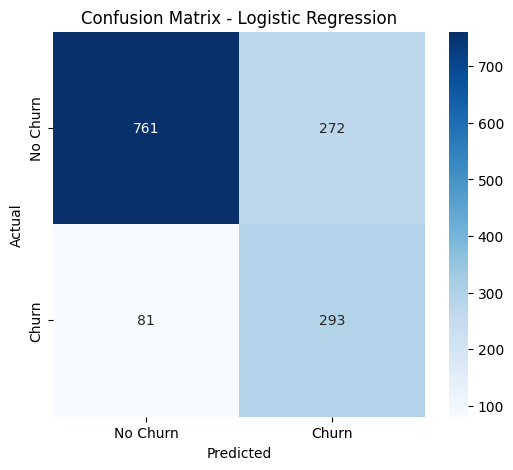

In [33]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_final = reg.predict(X_test)  # your Logistic Regression predictions

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

In [34]:
!pip install shap

   ---------------------------------------- 0.0/547.0 kB ? eta -:--:--
   ---------------------------------------- 547.0/547.0 kB 3.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------- ----------------- 1.6/2.8 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 6.8 MB/s  0:00:00
   ---------------------------------------- 0.0/41.9 MB ? eta -:--:--
   - -------------------------------------- 1.6/41.9 MB 8.4 MB/s eta 0:00:05
   -- ------------------------------------- 2.9/41.9 MB 7.0 MB/s eta 0:00:06
   --- ------------------------------------ 3.1/41.9 MB 6.8 MB/s eta 0:00:06
   --- ------------------------------------ 3.9/41.9 MB 4.7 MB/s eta 0:00:09
   ----- ---------------------------------- 5.2/41.9 MB 4.8 MB/s eta 0:00:08
   ------ --------------------------------- 6.3/41.9 MB 4.9 MB/s eta 0:00:08
   ------- -------------------------------- 7.9/41.9 MB 5.2 MB/s eta 0:00:07
   -------- -------------

In [36]:
feature_names = preprocessor.get_feature_names_out()
print(feature_names)
print(len(feature_names))

['cat__gender_Male' 'cat__Partner_Yes' 'cat__Dependents_Yes'
 'cat__PhoneService_Yes' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No internet service'
 'cat__OnlineSecurity_Yes' 'cat__OnlineBackup_No internet service'
 'cat__OnlineBackup_Yes' 'cat__DeviceProtection_No internet service'
 'cat__DeviceProtection_Yes' 'cat__TechSupport_No internet service'
 'cat__TechSupport_Yes' 'cat__StreamingTV_No internet service'
 'cat__StreamingTV_Yes' 'cat__StreamingMovies_No internet service'
 'cat__StreamingMovies_Yes' 'cat__Contract_One year'
 'cat__Contract_Two year' 'cat__PaperlessBilling_Yes'
 'cat__PaymentMethod_Credit card (automatic)'
 'cat__PaymentMethod_Electronic check' 'cat__PaymentMethod_Mailed check'
 'remainder__SeniorCitizen' 'remainder__tenure'
 'remainder__MonthlyCharges' 'remainder__TotalCharges_Cleaned']
30


In [37]:
import pandas as pd

X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=feature_names)
X_test_df = pd.DataFrame(X_test, columns=feature_names)

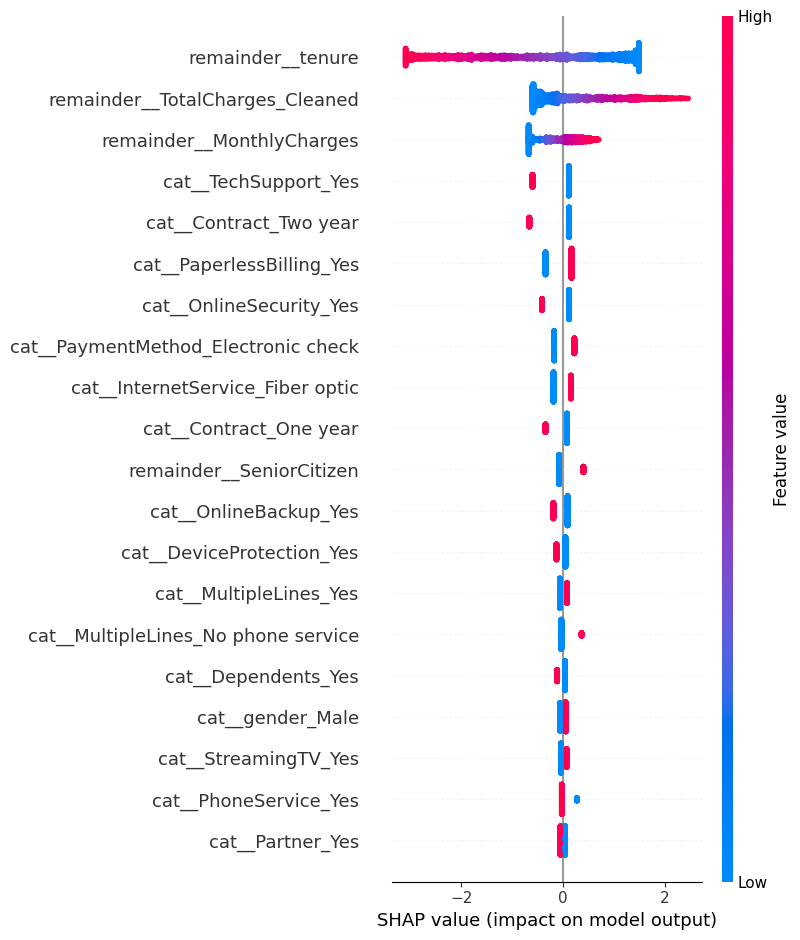

In [42]:
import shap
explainer = shap.Explainer(reg, X_train_resampled_df)
shap_values = explainer(X_test_df)

shap.summary_plot(shap_values, X_test_df)

In [43]:
X_full = df_features.drop(columns=['Churn'])
X_full_transformed = preprocessor.transform(X_full)
X_full_df = pd.DataFrame(X_full_transformed, columns=feature_names)

In [44]:
full_probabilities = reg.predict_proba(X_full_df)[:, 1]

c:\Users\LOQ\OneDrive\Desktop\PROJECTS\venv3\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [45]:
results = pd.DataFrame({
    'customerID': customer_ids.values,
    'Churn_actual': df_features['Churn'].values,
    'Churn_Probability': full_probabilities
})

active_customers_at_risk = results[results['Churn_actual'] == 'No'].sort_values(
    by='Churn_Probability', ascending=False
).head(50)

print(active_customers_at_risk)

      customerID Churn_actual  Churn_Probability
3632  5150-ITWWB           No           0.958257
4494  6350-XFYGW           No           0.941782
1744  2545-EBUPK           No           0.941159
2317  3320-VEOYC           No           0.941066
4696  6630-UJZMY           No           0.937847
3412  4847-TAJYI           No           0.936872
104   0187-QSXOE           No           0.934934
4407  6229-LSCKB           No           0.934496
17    0021-IKXGC           No           0.933410
2880  4115-NZRKS           No           0.932913
5121  7225-CBZPL           No           0.929868
6753  9603-OAIHC           No           0.929583
4941  6969-MVBAI           No           0.929555
4193  5935-FCCNB           No           0.928802
820   1197-BVMVG           No           0.928209
5785  8161-QYMTT           No           0.925549
2720  3878-AVSOQ           No           0.923339
1406  2077-MPJQO           No           0.923334
5357  7577-SWIFR           No           0.922739
4859  6860-YRJZP    